<a href="https://colab.research.google.com/github/redrosesarecool/staz/blob/main/krzywa_rotacji.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dane

In [3]:
# wgranie danych z pliku

from google.colab import files
uploaded = files.upload()

Saving r_v_montecarlo.dat to r_v_montecarlo.dat


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# wczytanie pliku
file_path = "r_v_montecarlo.dat"

# wczytanie danych do DataFrame
df = pd.read_csv(file_path, sep="\\s+", header=0)  # sep="\\s+" dla spacji
print(df.head())  # podgląd pierwszych wierszy


         R          V
0  2.15764  205.51122
1  2.29784  200.56563
2  2.43735  196.40169
3  2.57611  197.61817
4  2.71409  197.11383


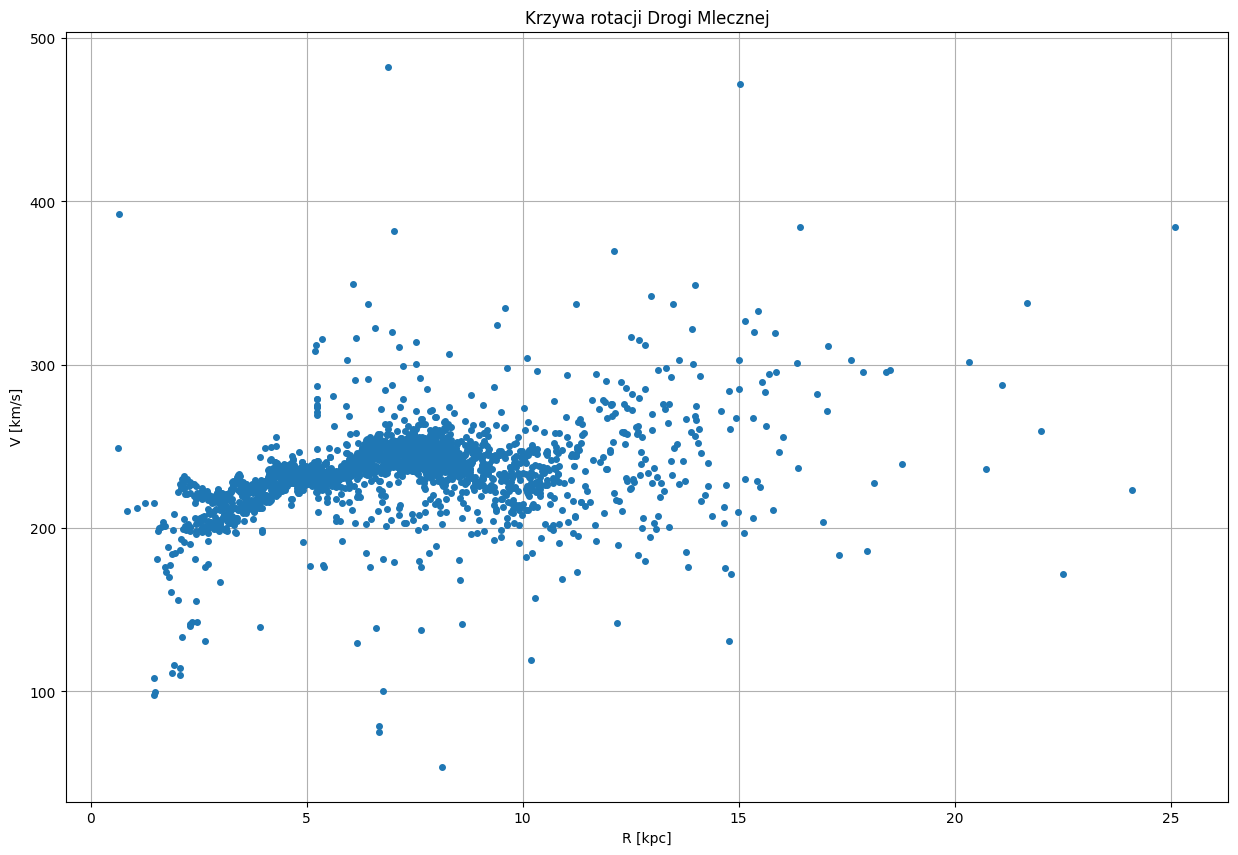

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# wykres R vs V
plt.figure(figsize=(15,10))
plt.plot(df["R"], df["V"], 'o', markersize=4)
plt.xlabel("R [kpc]")
plt.ylabel("V [km/s]")
plt.title("Krzywa rotacji Drogi Mlecznej")
plt.grid(True)
plt.show()

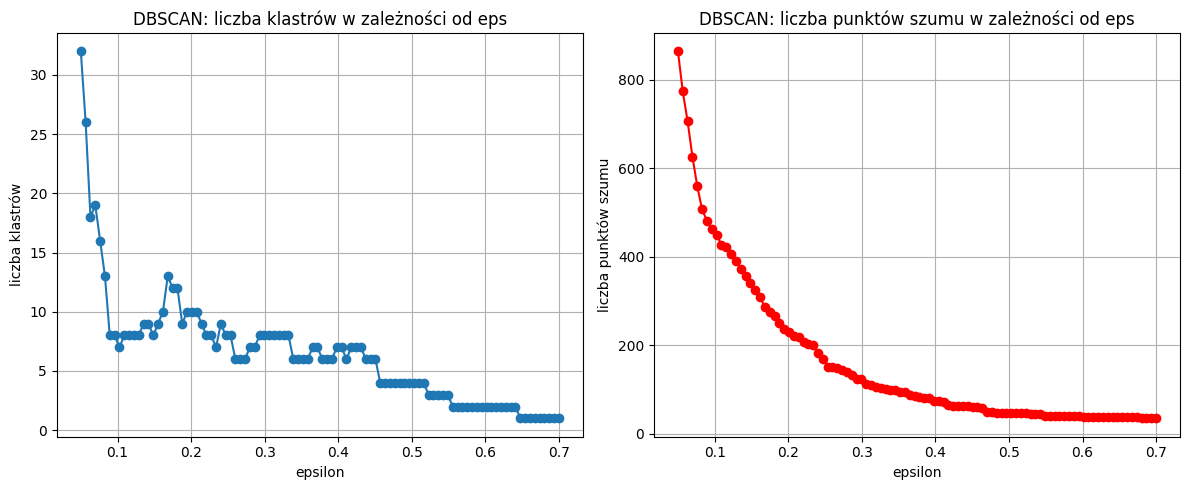

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# wczytanie danych z pliku
file_path = "r_v_montecarlo.dat"
df = df = pd.read_csv(file_path, sep="\\s+", header=0)

# skalowanie danych
X = df[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# parametry
eps_values = np.linspace(0.05, 0.7, 100)  # 100 kroków od 0.05 do 0.7
min_samples = 5

# listy do przechowywania wyników
n_clusters_list = []
n_noise_list = []

# pętla po epsilon
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_scaled)
    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    n_clusters_list.append(n_clusters)
    n_noise_list.append(n_noise)

# wykres
plt.figure(figsize=(12,5))

# liczba klastrów
plt.subplot(1,2,1)
plt.plot(eps_values, n_clusters_list, marker="o")
plt.xlabel("epsilon")
plt.ylabel("liczba klastrów")
plt.title("DBSCAN: liczba klastrów w zależności od eps")
plt.grid(True)

# liczba punktów szumu
plt.subplot(1,2,2)
plt.plot(eps_values, n_noise_list, marker="o", color="red")
plt.xlabel("epsilon")
plt.ylabel("liczba punktów szumu")
plt.title("DBSCAN: liczba punktów szumu w zależności od eps")
plt.grid(True)

plt.tight_layout()
plt.show()

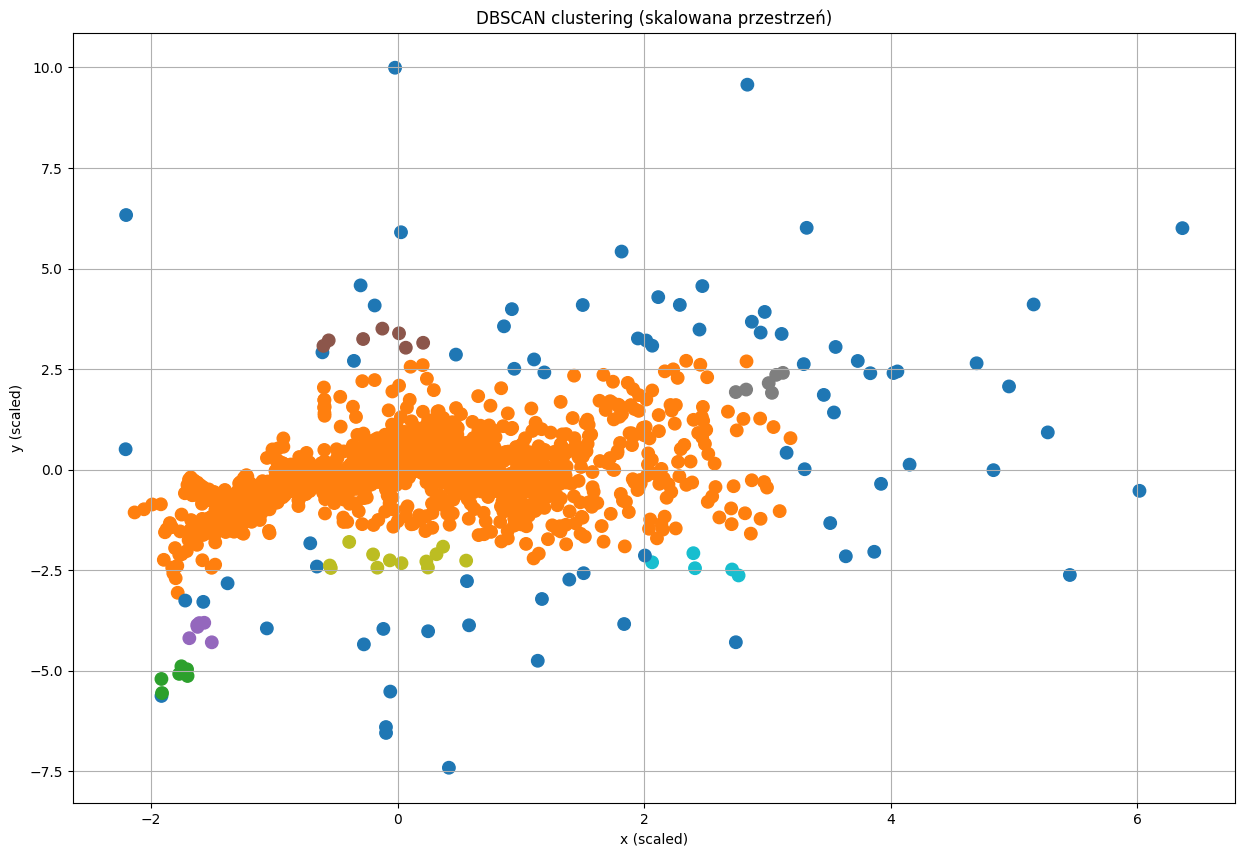

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X = df[["R", "V"]].values
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.4, min_samples=5).fit(X_scaled)

# etykiety klastrów
labels = db.labels_
df["cluster"] = labels

# wykres
plt.figure(figsize=(15,10))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["cluster"], cmap="tab10", s=80)
plt.xlabel("x (scaled)")
plt.ylabel("y (scaled)")
plt.title("DBSCAN clustering (skalowana przestrzeń)")
plt.grid(True)
plt.show()